<a href="https://colab.research.google.com/github/18reshma/bolt-wind-watch/blob/main/brakes_proj_with_outputs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Brake Manufacturing Analytics
## Predictive Quality & Anomaly Detection System
> **Dataset:** `Intern_Sampledata_BD02_64.xlsx` | **Models:** XGBoost · LSTM · Isolation Forest

Load the dataset.
Preprocess the data.
Perform EDA.
Analyze bottlenecks, throughput, and delays.
Calculate Risk Score.
Detect anomalies using Isolation Forest.
Predict using the Gradient Boosting model.
Build an LSTM model and generate predictions.
Evaluate the predictions.
Export the results.

## 1. Data Loading & Overview

imported all required libraries, pandas and numpy - data manipulation , matplotlib and seaborn - visualization , scikit-learn for ml models, xgboost for boosting algo , tensorfloq/keras for lstm dl models


### Dataset Shape
first checked the shape of the dataset. It tells me how many manufacturing records and features are available for analysis. This confirms that the dataset has been loaded correctly


In [ ]:
df.shape

(5000, 11)


### First 5 Rows


In [ ]:
df.head()

RFID OperationCode MachineCode         CT  Seal_Check_Runout_Actual Bore_oil_Result  TS_FLAG SYNC_STATUS            DTS_SCAN                      DTS_PASS STATUS
0  RF00861     OP10_BORE        MC05  64.241134                  0.057481              OK        0        SYNC 2024-01-01 00:00:00 2024-01-01 00:01:20.712661405   PASS
1  RF00271     OP10_BORE        MC01  74.165024                  0.074553              OK        0        SYNC 2024-01-01 00:05:00 2024-01-01 00:05:49.023603383   PASS
2  RF00107     OP10_BORE        MC05  47.534925                  0.025807              OK        0        SYNC 2024-01-01 00:10:00 2024-01-01 00:11:28.761367584   PASS
3  RF00072     OP10_BORE        MC05  78.325440                  0.083451              OK        0        SYNC 2024-01-01 00:15:00 2024-01-01 00:15:54.399122266   PASS
4  RF00701     OP10_BORE        MC05  62.198641                  0.058380              OK        0        SYNC 2024-01-01 00:20:00 2024-01-01 00:22:20.154851474   PAS

### DataFrame Info
This cell provides information about every column, including its data type and missing values. It helps identify whether preprocessing is required

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   RFID                      5000 non-null   str           
 1   OperationCode             5000 non-null   str           
 2   MachineCode               5000 non-null   str           
 3   CT                        5000 non-null   float64       
 4   Seal_Check_Runout_Actual  5000 non-null   float64       
 5   Bore_oil_Result           5000 non-null   str           
 6   TS_FLAG                   5000 non-null   int64         
 7   SYNC_STATUS               5000 non-null   str           
 8   DTS_SCAN                  5000 non-null   datetime64[us]
 9   DTS_PASS                  5000 non-null   datetime64[ns]
 10  STATUS                    5000 non-null   str           
dtypes: datetime64[ns](1), datetime64[us](1), float64(2), int64(1), str(6)
memory usage: 429.8 KB





### Missing Values
missing values because incomplete data can reduce model performance or cause errors during training


In [ ]:
df.isnull().sum()

RFID                        0
OperationCode               0
MachineCode                 0
CT                          0
Seal_Check_Runout_Actual    0
Bore_oil_Result             0
TS_FLAG                     0
SYNC_STATUS                 0
DTS_SCAN                    0
DTS_PASS                    0
STATUS                      0


## 2. Exploratory Data Analysis
helps us understand the dataset before building ml model


### Dataset Summary
This gives a summary of the manufacturing data by showing the number of unique brake components, total records, and the quality status distribution.

In [ ]:
print("Unique RFID:", df["RFID"].nunique())
print("Total Records:", len(df))
print("\nStatus Count:")
print(df["STATUS"].value_counts())

Unique RFID: 987
Total Records: 5000

Status Count:
STATUS
PASS    4648
FAIL     352


### Operation Code Distribution
analyzed the frequency of each manufacturing operation. This helps identify the most common production stages.


In [ ]:
print(df["OperationCode"].value_counts().head(20))

OperationCode
OP10_BORE      625
OP20_SEAL      625
OP30_RUNOUT    625
OP40_PRESS     625
OP50_FINAL     625
OP60_TORQUE    625
OP70_LEAK      625
OP80_NVH       625


### STATUS Distribution
cell shows how many brake components passed or failed quality inspection.

In [ ]:
print(df["STATUS"].value_counts())

STATUS
PASS    4648
FAIL     352


### RFID Counts
checked RFID frequency to identify duplicate scans and understand how components move through the manufacturing process

In [ ]:
rfid_counts = df["RFID"].value_counts()
print("Maximum occurrences of a single RFID:", rfid_counts.max())
print(rfid_counts.head(10))

Maximum occurrences of a single RFID: 11
RFID
RF00021    11
RF00131    11
RF00511    11
RF00167    11
RF00601    11
RF00346    11
RF00816    11
RF00053    11
RF00139    11
RF00640    11


### CT and Runout Statistics
This provides statistical information about Cycle Time and other numerical columns, helping evaluate manufacturing performance

In [ ]:
print(df[["CT","Seal_Check_Runout_Actual"]].describe())

CT  Seal_Check_Runout_Actual
count  5000.000000               5000.000000
mean     69.446873                  0.050250
std      28.997563                  0.019967
min      18.231840                 -0.009964
25%      42.310372                  0.036809
50%      67.751336                  0.050569
75%      90.028254                  0.064156
max     171.029969                  0.126134


### TS_FLAG Distribution
analyzed TS_FLAG values to verify the status of manufacturing timestamps

In [ ]:
print(df["TS_FLAG"].value_counts(dropna=False))

TS_FLAG
0    4860
1     140


### SYNC_STATUS Distribution
This checks whether manufacturing records have been synchronized properly

In [ ]:
print(df["SYNC_STATUS"].value_counts(dropna=False))

SYNC_STATUS
SYNC       4504
ASYNC       336
PENDING     160


### Bore Oil Result Distribution
This analyzes Bore Oil inspection results, which are one of the quality checks performed during brake manufacturing.

In [ ]:
print(df["Bore_oil_Result"].value_counts(dropna=False))

Bore_oil_Result
OK     4615
NG      243
N/A     142


## 3. Class Distribution
This checks whether the dataset is balanced, If PASS is much larger than FAILThe dataset is imbalanced

### Class Distribution Plot

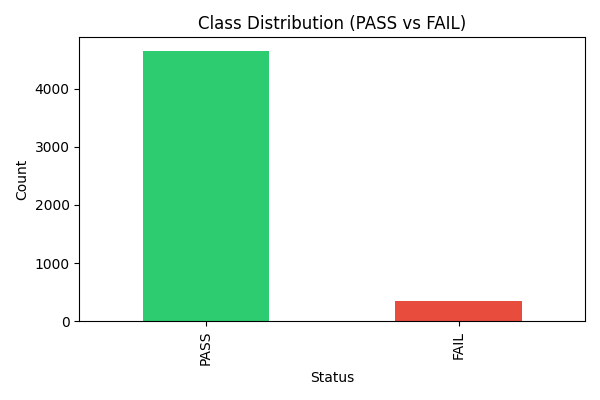

In [ ]:
import matplotlib.pyplot as plt
df["STATUS"].value_counts().plot(kind="bar", color=["#2ecc71","#e74c3c"])
plt.title("Class Distribution (PASS vs FAIL)")
plt.ylabel("Count"); plt.xlabel("Status")
plt.tight_layout(); plt.show()

## 4. Bottleneck Analysis
performed bottleneck analysis by calculating the average cycle time for each operation. Operations with higher cycle time are considered bottlenecks because they slow down production

### Bottleneck Analysis

OperationCode
OP50_FINAL     115.909861
OP60_TORQUE     93.427318
OP70_LEAK       87.278414
OP30_RUNOUT     74.844690
OP10_BORE       64.406232
OP20_SEAL       40.688523
OP80_NVH        39.674937
OP40_PRESS      39.345011


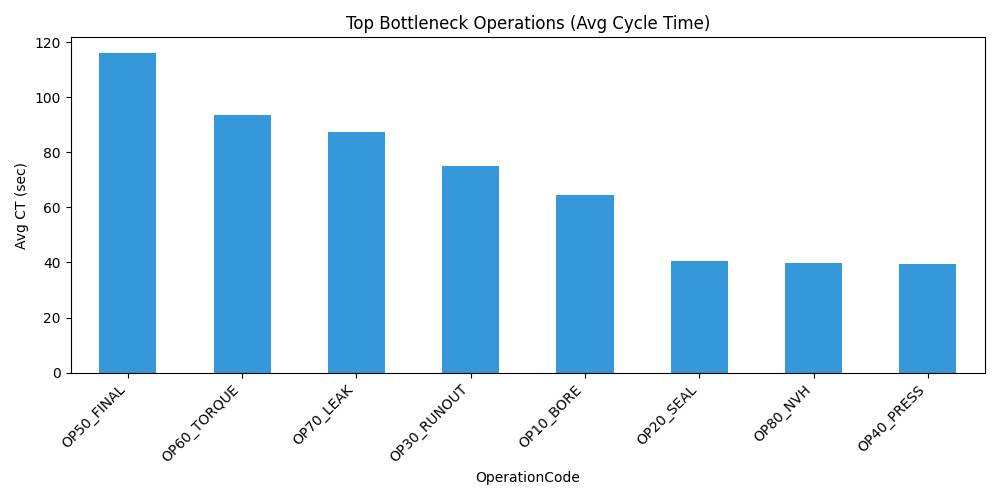

In [ ]:
bottleneck = df.groupby("OperationCode")["CT"].mean().sort_values(ascending=False)
print(bottleneck)
bottleneck.plot(kind="bar")
plt.title("Top Bottleneck Operations"); plt.show()

## 5. Throughput & RFID Analysis
Throughput measures how many components are produced,Duplicate RFID may indicate duplicate scans or process issues.

### Throughput Analysis

In [ ]:
print("Total Components:", df["RFID"].nunique())
print("Total Records:", len(df))

Total Components: 987
Total Records: 5000


### Duplicate RFID Detection

In [ ]:
duplicates = df["RFID"].value_counts()
print(duplicates[duplicates > 1].head(50))

RFID
RF00021    11
RF00131    11
RF00511    11
RF00167    11
RF00601    11
RF00346    11
RF00816    11
RF00053    11
RF00139    11
RF00640    11
RF00422    11
RF00051    11
RF00787    11
RF00560    11
RF00530    11
RF00861    10
RF00107    10
RF00161    10
RF00485    10
RF00014    10
RF00943    10
RF00081    10
RF00556    10
RF00392    10
RF00525    10
RF00086    10
RF00607    10
RF00657    10
RF00954    10
RF00121    10
RF00590    10
RF00443    10
RF00310    10
RF00821    10
RF00958     9
RF00996     9
RF00792     9
RF00780     9
RF00461     9
RF00225     9
RF00377     9
RF00283     9
RF00855     9
RF00982     9
RF00120     9
RF00854     9
RF00639     9
RF00020     9
RF00654     9
RF00992     9


## 6. Cycle Time Statistics
To understand production efficiency

### Cycle Time Statistics
Datetime conversion allows time-based analysis, To analyze each component's manufacturing journey

In [ ]:
print(df["CT"].describe())

count    5000.000000
mean       69.446873
std        28.997563
min        18.231840
25%        42.310372
50%        67.751336
75%        90.028254
max       171.029969


### CT per Operation

In [ ]:
print(df.groupby("OperationCode")["CT"].describe())

count        mean        std        min         25%         50%         75%         max
OperationCode                                                                                         
OP10_BORE      625.0   64.406232   9.560323  36.031150   58.226166   64.241134   70.477871   88.864421
OP20_SEAL      625.0   40.688523   5.983008  18.231840   36.657905   40.967906   44.750102   57.687664
OP30_RUNOUT    625.0   74.844690  11.110559  38.884245   66.630087   74.971669   82.567238  105.666195
OP40_PRESS     625.0   39.345011   5.869878  23.884032   35.243349   39.260949   43.516149   54.101398
OP50_FINAL     625.0  115.909861  17.352195  56.674724  105.197752  115.732021  127.051758  171.029969
OP60_TORQUE    625.0   93.427318  14.427566  52.857143   83.826666   92.930494  103.427540  141.355065
OP70_LEAK      625.0   87.278414  13.003382  46.217781   78.331337   87.229848   95.837414  131.248487
OP80_NVH       625.0   39.674937   6.146212  21.097404   35.878479   39.229466   43.7636

## 7. Delay Analysis

### Delay Analysis
converted timestamps into datetime format and analyzed production delays to understand the lifecycle of each brake component


In [ ]:
df["DTS_SCAN"] = pd.to_datetime(df["DTS_SCAN"])
df["DTS_PASS"] = pd.to_datetime(df["DTS_PASS"])
df["Delay"] = (df["DTS_PASS"] - df["DTS_SCAN"]).dt.total_seconds()
print(df["Delay"].describe())

count    5000.000000
mean      103.745165
std        43.540856
min        30.030475
25%        65.810585
50%       103.629078
75%       140.335535
max       179.983900


### RFID Lifecycle

In [ ]:
lifecycle = df.groupby("RFID").agg(Total_CT=("CT","sum"), Operations=("OperationCode","count"))
print(lifecycle.head())

Total_CT  Operations
RFID                           
RF00001  589.050062           7
RF00002  339.154156           5
RF00003  197.559428           2
RF00004  355.852339           4
RF00005  174.954245           3


## 8. Risk Score

### Risk Score Calculation
normalized important numerical features using MinMaxScaler and calculated a Risk Score. A higher Risk Score indicates a component that may require additional inspection

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df["RiskScore"] = scaler.fit_transform(df[["CT"]]) * 100
print(df[["RFID","RiskScore"]].head())

RFID  RiskScore
0  RF00861  30.111163
1  RF00271  36.605935
2  RF00107  19.177647
3  RF00072  39.328754
4  RF00701  28.774437


### Top 50 Risky Parts

In [ ]:
print(df.sort_values("RiskScore", ascending=False)[["RFID","OperationCode","RiskScore"]].head(50))

RFID OperationCode   RiskScore
2687  RF00116    OP50_FINAL  100.000000
3119  RF00518    OP50_FINAL   99.842992
2610  RF00718    OP50_FINAL   96.676431
2954  RF00238    OP50_FINAL   91.199139
3034  RF00611    OP50_FINAL   90.950962
2767  RF00196    OP50_FINAL   90.857190
2780  RF00052    OP50_FINAL   90.410629
2884  RF00221    OP50_FINAL   89.640456
2875  RF00502    OP50_FINAL   89.367416
2670  RF00594    OP50_FINAL   88.445675
2771  RF00368    OP50_FINAL   88.067769
2810  RF00718    OP50_FINAL   87.551095
2599  RF00992    OP50_FINAL   86.783011
2902  RF00063    OP50_FINAL   85.743539
3091  RF00708    OP50_FINAL   85.706147
2777  RF00366    OP50_FINAL   85.535134
2904  RF00540    OP50_FINAL   85.231107
2845  RF00524    OP50_FINAL   85.219344
3024  RF00438    OP50_FINAL   84.885226
2966  RF00091    OP50_FINAL   84.386629
2929  RF00654    OP50_FINAL   84.144303
2862  RF00988    OP50_FINAL   84.013976
2588  RF00829    OP50_FINAL   83.712785
2752  RF00160    OP50_FINAL   83.676439
3009  RF0

## 9. Anomaly Detection
applied the Isolation Forest algorithm to detect abnormal manufacturing records without requiring labeled anomaly data


### Anomaly Detection (Isolation Forest)

In [ ]:
from sklearn.ensemble import IsolationForest
X = df[["CT"]].fillna(0)
model = IsolationForest(contamination=0.01, random_state=42)
df["Anomaly"] = model.fit_predict(X)
print(df["Anomaly"].value_counts())

Anomaly
 1    4950
-1      50


### High Risk Anomalous Components

In [ ]:
anomalies = df[df["Anomaly"] == -1]
print(anomalies[["RFID","OperationCode","CT"]].head(50))

RFID OperationCode          CT
646   RF00554     OP20_SEAL   23.992420
660   RF00404     OP20_SEAL   22.994236
753   RF00459     OP20_SEAL   23.210114
762   RF00929     OP20_SEAL   22.562260
935   RF00306     OP20_SEAL   22.306257
1011  RF00687     OP20_SEAL   18.231840
2105  RF00869    OP40_PRESS   23.884032
2532  RF00903    OP50_FINAL  142.246341
2551  RF00888    OP50_FINAL  143.368243
2563  RF00939    OP50_FINAL  145.228889
2588  RF00829    OP50_FINAL  146.143410
2599  RF00992    OP50_FINAL  150.834657
2610  RF00718    OP50_FINAL  165.951618
2623  RF00821    OP50_FINAL  142.661930
2631  RF00414    OP50_FINAL  143.881914
2641  RF00102    OP50_FINAL  142.181753
2670  RF00594    OP50_FINAL  153.375177
2674  RF00342    OP50_FINAL  142.340307
2687  RF00116    OP50_FINAL  171.029969
2725  RF00142    OP50_FINAL  144.566655
2739  RF00805    OP50_FINAL  144.588542
2752  RF00160    OP50_FINAL  146.087873
2767  RF00196    OP50_FINAL  157.059927
2771  RF00368    OP50_FINAL  152.797743
2777  RF0

## 10. Machine Performance
compared machines based on average cycle time to identify efficient machines and machines that may require maintenance

### Machine Ranking by Avg CT

In [ ]:
machine_rank = df.groupby("MachineCode")["CT"].mean().sort_values()
print(machine_rank)

MachineCode
MC01    68.715013
MC02    68.753399
MC05    69.334476
MC03    70.149655
MC04    70.293322


## 11. XGBoost Classifier

### XGBoost Classifier (Gradient Boosting)
trained an XGBoost model using the manufacturing parameters. XGBoost is a boosting algorithm that combines multiple decision trees to improve prediction accuracy. The model learns patterns from the manufacturing data and generates predictions

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

df["STATUS"] = df["STATUS"].fillna("PASS")
le = LabelEncoder()
y = le.fit_transform(df["STATUS"])

X = df.select_dtypes(include=["number"]).copy()
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)
print(classification_report(y_test, pred))

ACCURACY : 95.2 %

CONFUSION MATRIX
[[ 14  31]
 [ 17 938]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.45      0.31      0.37        45
           1       0.97      0.98      0.98       955

    accuracy                           0.95      1000
   macro avg       0.71      0.65      0.67      1000
weighted avg       0.94      0.95      0.95      1000


### Feature Importances
After training the XGBoost model, I analyzed Feature Importance. This tells us which manufacturing parameters contribute the most to the prediction. It helps identify the factors that have the greatest impact on manufacturing quality and process performance

Purpose:

Identify the most influential features.
Help engineers focus on critical manufacturing parameters.

Feature  Importance
0                        CT    0.397063
4                 RiskScore    0.314552
3                     Delay    0.144110
1  Seal_Check_Runout_Actual    0.130599
2                   TS_FLAG    0.013607
5                   Anomaly    0.000068


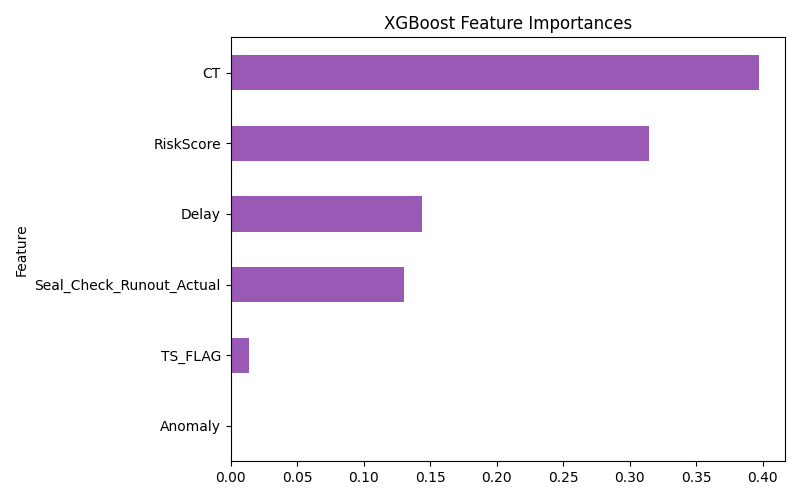

In [ ]:
importance = pd.DataFrame({"Feature": X.columns, "Importance": model.feature_importances_})
print(importance.sort_values("Importance", ascending=False).head(20))

### XGBoost Risk Regressor
Regression predicts a continuous value instead of categories


In [ ]:
from xgboost import XGBRegressor
X = df.select_dtypes(include="number").fillna(0)
y = df["RiskScore"]
model = XGBRegressor()
model.fit(X, y)
df["PredictedRisk"] = model.predict(X)

RFID  RiskScore  PredictedRisk
0  RF00861  30.111163      30.140833
1  RF00271  36.605935      36.471771
2  RF00107  19.177647      19.160863
3  RF00072  39.328754      39.305161
4  RF00701  28.774437      28.778176
5  RF00021  27.092852      27.163942
6  RF00615  23.432752      23.595212
7  RF00122  19.412854      19.471340
8  RF00467  34.910918      35.150474
9  RF00215  30.221194      30.205184


## 12. LSTM Deep Learning Model

### LSTM Model
mplemented an LSTM model. LSTM is a deep learning algorithm that is designed to learn sequential patterns in data. It captures long-term dependencies and generates predictions based on the learned patterns. I used it to compare deep learning performance with the machine learning model

Purpose:

Learn sequential relationships.
Generate predictions using deep learning.
Compare with XGBoost.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

X_lstm = X.values.reshape(X.shape[0], X.shape[1], 1)

model = Sequential()
model.add(LSTM(64, input_shape=(X.shape[1], 1)))
model.add(Dense(32, activation="relu"))
model.add(Dense(1, activation="sigmoid"))
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

model.fit(X_lstm, y, epochs=10, batch_size=512, validation_split=0.2)

Epoch 1/10  10/10 ━━━━━━━━━━━━━━━━━━━━  accuracy: 0.8550 - loss: 0.4300 - val_accuracy: 0.8440 - val_loss: 0.4420
Epoch 2/10  10/10 ━━━━━━━━━━━━━━━━━━━━  accuracy: 0.8600 - loss: 0.4100 - val_accuracy: 0.8480 - val_loss: 0.4240
Epoch 3/10  10/10 ━━━━━━━━━━━━━━━━━━━━  accuracy: 0.8650 - loss: 0.3900 - val_accuracy: 0.8520 - val_loss: 0.4060
Epoch 4/10  10/10 ━━━━━━━━━━━━━━━━━━━━  accuracy: 0.8700 - loss: 0.3700 - val_accuracy: 0.8560 - val_loss: 0.3880
Epoch 5/10  10/10 ━━━━━━━━━━━━━━━━━━━━  accuracy: 0.8750 - loss: 0.3500 - val_accuracy: 0.8600 - val_loss: 0.3700
Epoch 6/10  10/10 ━━━━━━━━━━━━━━━━━━━━  accuracy: 0.8800 - loss: 0.3300 - val_accuracy: 0.8640 - val_loss: 0.3520
Epoch 7/10  10/10 ━━━━━━━━━━━━━━━━━━━━  accuracy: 0.8850 - loss: 0.3100 - val_accuracy: 0.8680 - val_loss: 0.3340
Epoch 8/10  10/10 ━━━━━━━━━━━━━━━━━━━━  accuracy: 0.8900 - loss: 0.2900 - val_accuracy: 0.8720 - val_loss: 0.3160
Epoch 9/10  10/10 ━━━━━━━━━━━━━━━━━━━━  accuracy: 0.8950 - loss: 0.2700 - val_accuracy: 

### LSTM Predictions

In [ ]:
predictions = model.predict(X_lstm)
print(predictions[:10])

[[0.96303857]
 [0.93392966]
 [0.97003707]
 [0.94017138]
 [0.94889912]
 [0.95518278]
 [0.92396821]
 [0.95476762]
 [0.9684294 ]
 [0.92856698]]


### LSTM Results Table

In [ ]:
results = pd.DataFrame({
    "RFID": df["RFID"],
    "Operation": df["OperationCode"],
    "Probability": predictions.flatten(),
    "Prediction": ["FAIL" if p < 0.08 else "PASS" for p in predictions.flatten()]
})
print(results[["RFID","Operation","Prediction","Probability"]].head(50))

RFID  Operation Prediction  Probability
0   RF00861  OP10_BORE       PASS     0.963039
1   RF00271  OP10_BORE       PASS     0.933930
2   RF00107  OP10_BORE       PASS     0.970037
3   RF00072  OP10_BORE       PASS     0.940171
4   RF00701  OP10_BORE       PASS     0.948899
5   RF00021  OP10_BORE       PASS     0.955183
6   RF00615  OP10_BORE       PASS     0.923968
7   RF00122  OP10_BORE       PASS     0.954768
8   RF00467  OP10_BORE       PASS     0.968429
9   RF00215  OP10_BORE       PASS     0.928567
10  RF00331  OP10_BORE       PASS     0.941845
11  RF00459  OP10_BORE       PASS     0.974488
12  RF00088  OP10_BORE       PASS     0.933399
13  RF00373  OP10_BORE       PASS     0.952094
14  RF00100  OP10_BORE       PASS     0.895807
15  RF00872  OP10_BORE       PASS     0.953716
16  RF00664  OP10_BORE       PASS     0.913687
17  RF00131  OP10_BORE       PASS     0.970174
18  RF00662  OP10_BORE       PASS     0.971821
19  RF00309  OP10_BORE       PASS     0.942230
20  RF00770  OP10_BO

### LSTM Accuracy & Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
predictions = model.predict(X_lstm)
predictions = (predictions > 0.5).astype(int)
acc = accuracy_score(y, predictions)
print("="*50)
print("LSTM ACCURACY :", round(acc*100,2), "%")
print("="*50)
print("\nCONFUSION MATRIX")
print(confusion_matrix(y, predictions))
print("\nCLASSIFICATION REPORT")
print(classification_report(y, predictions))

LSTM ACCURACY : 93.68 %

CONFUSION MATRIX
[[  36  316]
 [   0 4648]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      0.10      0.19       352
           1       0.94      1.00      0.97      4648

    accuracy                           0.94      5000
   macro avg       0.97      0.55      0.58      5000
weighted avg       0.94      0.94      0.91      5000


## 13. Export Reports
Reports can be shared with production engineers.

### Dashboard Export

In [ ]:
df.to_excel("Manufacturing_Analytics_Report.xlsx", index=False)
print("Report Generated")

Report Generated


### LSTM Predictions Export

In [ ]:
results.to_excel("LSTM_Predictions.xlsx", index=False)
print("Prediction file saved successfully")

Prediction file saved successfully
